In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("data/flattened_global_scaled.csv", sep=";")

# Suppression des lignes de la classe "Mixtes" pour passer à un problème binaire
df = df[df["classe_name"] != "Mixtes"]

# Encodage textuel de la colonne cible ("CCK" et "CHC" -> 0 et 1)
label_encoder = LabelEncoder()
df["target"] = label_encoder.fit_transform(df["classe_name"])

# Sélection de toutes les features (en excluant les identifiants et la cible)
metadata_cols = ["id", "patient_num", "classe_name", "target"]
feature_cols = [col for col in df.columns if col not in metadata_cols]

X = df[feature_cols].values
y = df["target"].values

# Découpage 80% train / 20% test avec stratification binaire
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


C:\Users\cleme\AppData\Local\Temp\ipykernel_65192\2261246930.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["target"] = label_encoder.fit_transform(df["classe_name"])


In [3]:
model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.5,
    random_state=42,
)

model.fit(X_train, y_train)

# Création d'un DataFrame pour associer les colonnes à leurs coefficients
df_coefs = pd.DataFrame(
    {"Feature": feature_cols, "Coefficient": model.coef_[0]}
)

# Filtrer pour ne garder que les coefficients actifs (différents de zéro)
df_actifs = df_coefs[df_coefs["Coefficient"] != 0]

# Trier par valeur absolue pour voir les variables les plus discriminantes en premier
df_actifs = df_actifs.reindex(
    df_actifs["Coefficient"].abs().sort_values(ascending=False).index
)

# Affichage des résultats
print(f"Nombre de features actives : {len(df_actifs)}")
print(df_actifs.to_string(index=False))


Nombre de features actives : 16
                                               Feature  Coefficient
                        original_shape_Sphericity_PORT     0.845447
                 original_gldm_DependenceVariance_PORT     0.534582
                     original_firstorder_Skewness_PORT     0.516820
                                                Gender     0.235438
      original_glszm_SmallAreaLowGrayLevelEmphasis_ART     0.234221
             original_glrlm_GrayLevelNonUniformity_ART     0.228108
                           original_ngtdm_Busyness_ART     0.203912
                  original_gldm_DependenceVariance_ART     0.202661
original_gldm_SmallDependenceLowGrayLevelEmphasis_TARD    -0.199737
                      original_firstorder_Minimum_PORT     0.137959
             original_glszm_GrayLevelNonUniformity_ART     0.082482
                        original_shape_Sphericity_TARD     0.065516
                           original_shape_Flatness_ART    -0.057079
                

C:\Users\cleme\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\cleme\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [4]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

# En binaire, la matrice de coefficients est de dimension (1, n_features)
total_coefficients = model.coef_.size
coefficients_actifs = (model.coef_ != 0).sum()

print(f"Accuracy Train : {acc_train * 100:.2f}%")
print(f"Accuracy Test  : {acc_test * 100:.2f}%")
print(
    f"Sélection Lasso : {coefficients_actifs} coefficients actifs sur un total de {total_coefficients}\n"
)

print("Rapport de classification détaillé (Test) :")
print(
    classification_report(
        y_test, y_pred_test, target_names=label_encoder.classes_
    )
)


Accuracy Train : 93.42%
Accuracy Test  : 89.47%
Sélection Lasso : 16 coefficients actifs sur un total de 320

Rapport de classification détaillé (Test) :
              precision    recall  f1-score   support

         CCK       0.75      0.75      0.75         4
         CHC       0.93      0.93      0.93        15

    accuracy                           0.89        19
   macro avg       0.84      0.84      0.84        19
weighted avg       0.89      0.89      0.89        19



In [5]:
# 1. On recharge le dataset complet pour récupérer les lignes "Mixtes" qu'on avait filtrées
df_complet = pd.read_csv("data/flattened_global_scaled.csv", sep=";")
df_mixtes = df_complet[df_complet["classe_name"] == "Mixtes"]

print(f"📊 Nombre de patients Mixtes à évaluer : {len(df_mixtes)}")

# 2. Extraction des mêmes caractéristiques (features) que pour l'entraînement
X_mixtes = df_mixtes[feature_cols].values

# 3. Prédiction des probabilités continues (score entre 0 et 1)
# predict_proba renvoie [prob_classe_0, prob_classe_1]
# Alphabétiquement, 'CCK' (classe 0) vient avant 'CHC' (classe 1). 
# L'index [:, 1] correspond donc à la probabilité d'être un CHC.
prob_chc_mixtes = model.predict_proba(X_mixtes)[:, 1]

# On stocke le résultat dans notre DataFrame pour analyse
df_mixtes = df_mixtes.copy()
df_mixtes["prob_CHC"] = prob_chc_mixtes

# Récupération dynamique des noms de classes depuis ton LabelEncoder
nom_classe_0 = label_encoder.classes_[0] # 'CCK'
nom_classe_1 = label_encoder.classes_[1] # 'CHC'



📊 Nombre de patients Mixtes à évaluer : 31


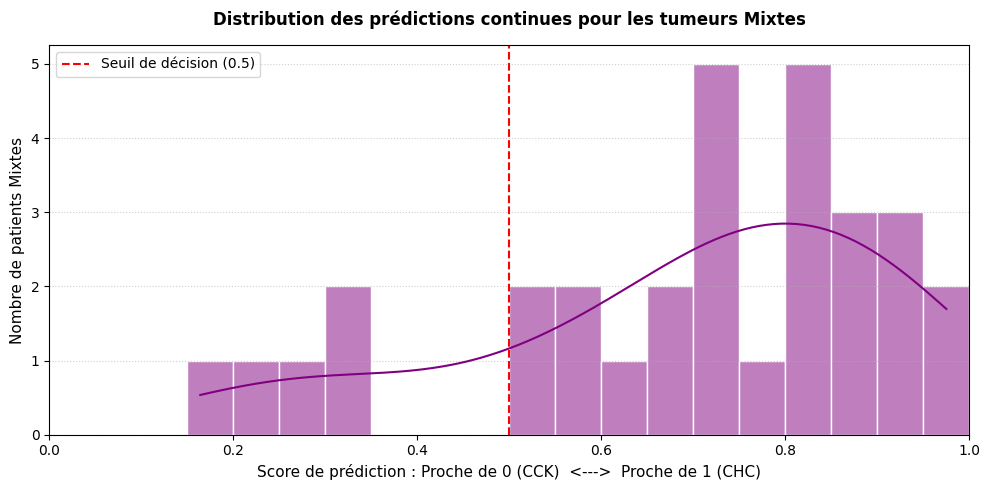

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

# Tracé de l'histogramme avec courbe de densité lissée (KDE)
sns.histplot(
    data=df_mixtes, 
    x="prob_CHC", 
    bins=20, 
    kde=True, 
    color="purple",
    edgecolor="white",
    binrange=(0, 1)
)

# Ajout d'une ligne repère à 0.5 (le seuil décisionnel habituel)
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, label='Seuil de décision (0.5)')

# Mise en forme du graphique
plt.title("Distribution des prédictions continues pour les tumeurs Mixtes", fontsize=12, fontweight='bold', pad=15)
plt.xlabel(f"Score de prédiction : Proche de 0 ({nom_classe_0})  <--->  Proche de 1 ({nom_classe_1})", fontsize=11)
plt.ylabel("Nombre de patients Mixtes", fontsize=11)
plt.xlim(0, 1)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()



In [7]:
nb_proche_cck = (prob_chc_mixtes < 0.5).sum()
nb_proche_chc = (prob_chc_mixtes >= 0.5).sum()

print("\n📈 RÉPARTITION DES PRÉDICTIONS :")
print("-" * 40)
print(f"⬅️ Plus proche du profil {nom_classe_0} (< 0.5)  : {nb_proche_cck} patients ({nb_proche_cck/len(df_mixtes)*100:.1f}%)")
print(f"➡️ Plus proche du profil {nom_classe_1} (>= 0.5) : {nb_proche_chc} patients ({nb_proche_chc/len(df_mixtes)*100:.1f}%)")
print("-" * 40)


📈 RÉPARTITION DES PRÉDICTIONS :
----------------------------------------
⬅️ Plus proche du profil CCK (< 0.5)  : 5 patients (16.1%)
➡️ Plus proche du profil CHC (>= 0.5) : 26 patients (83.9%)
----------------------------------------
